**Train** -- Learning patterns, literally training data

**Validation** -- Monitors performance during training and tunes hyperparameters

**Test** -- Evaluates final model performance on **completely unseen** data

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("loading dataset...")

labeled_dataset = pd.read_csv('data/labeled_processed.csv')

print("dataset loaded!")

train, temp = train_test_split(
    labeled_dataset,
    test_size=0.3,
    random_state=1,
    stratify=labeled_dataset['event_type']
)
val, test = train_test_split(
    temp,
    test_size=0.5,
    random_state=1,
    stratify=temp['event_type']
)

fields_to_drop = [
    'sample', 'file_name', 'ML_1', 'ML_1_1', 'ML_1_1_1', 'ML_1_2','ML_2','ML_2_1_1','ML_2_1_2','ML_2_1_3','ML_2_2','ML_2_3',
    'ML_2_3_1','ML_2_4_1','ML_2_4_2','ML_2_5_1','ML_2_6','ML_2_7_1','ML_2_7_2','ML_3','ML_3_1','ML_3_2','ML_3_3','ML_3_4',
    'ML_3_5', 'event_type']

train_features = train.drop(fields_to_drop, axis=1)
train_labels = train['event_type']

val_features = val.drop(fields_to_drop, axis=1)
val_labels = val['event_type']

test_features = test.drop(fields_to_drop, axis=1)
test_labels = test['event_type']


loading dataset...
dataset loaded!


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.7603020	test: 0.7603634	best: 0.7603634 (0)	total: 1.89s	remaining: 15m 41s
1:	learn: 0.8238096	test: 0.8240683	best: 0.8240683 (1)	total: 3.78s	remaining: 15m 40s
2:	learn: 0.8313826	test: 0.8317259	best: 0.8317259 (2)	total: 5.65s	remaining: 15m 35s
3:	learn: 0.8379615	test: 0.8382707	best: 0.8382707 (3)	total: 7.51s	remaining: 15m 31s
4:	learn: 0.8433568	test: 0.8436011	best: 0.8436011 (4)	total: 10.1s	remaining: 16m 41s
5:	learn: 0.8482164	test: 0.8484537	best: 0.8484537 (5)	total: 12.2s	remaining: 16m 42s
6:	learn: 0.8504736	test: 0.8506336	best: 0.8506336 (6)	total: 14s	remaining: 16m 29s
7:	learn: 0.8514133	test: 0.8514619	best: 0.8514619 (7)	total: 15.9s	remaining: 16m 18s
8:	learn: 0.8599695	test: 0.8600900	best: 0.8600900 (8)	total: 17.8s	remaining: 16m 9s
9:	learn: 0.8654911	test: 0.8655373	best: 0.8655373 (9)	total: 19.7s	remaining: 16m 3s
10:	learn: 0.8697736	test: 0.8697700	best: 0.8697700 (10)	total: 21.5s	remaining: 15m 56s
11:	learn: 0.8740735	test: 0.87394

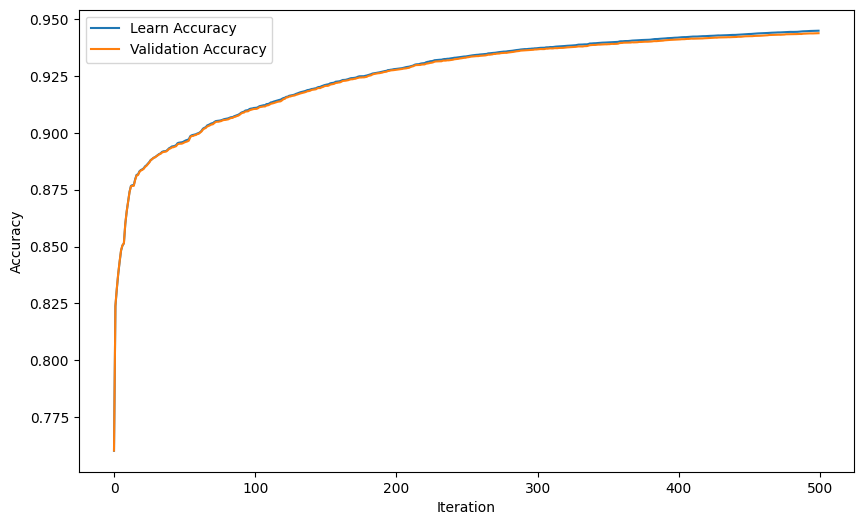

Best Train Accuracy: 0.9448700066311481
Best Validation Accuracy: 0.9437799164625656
Score Validation Accuracy: 0.9438154859297351
Score Test Accuracy: 0.9435058104970045


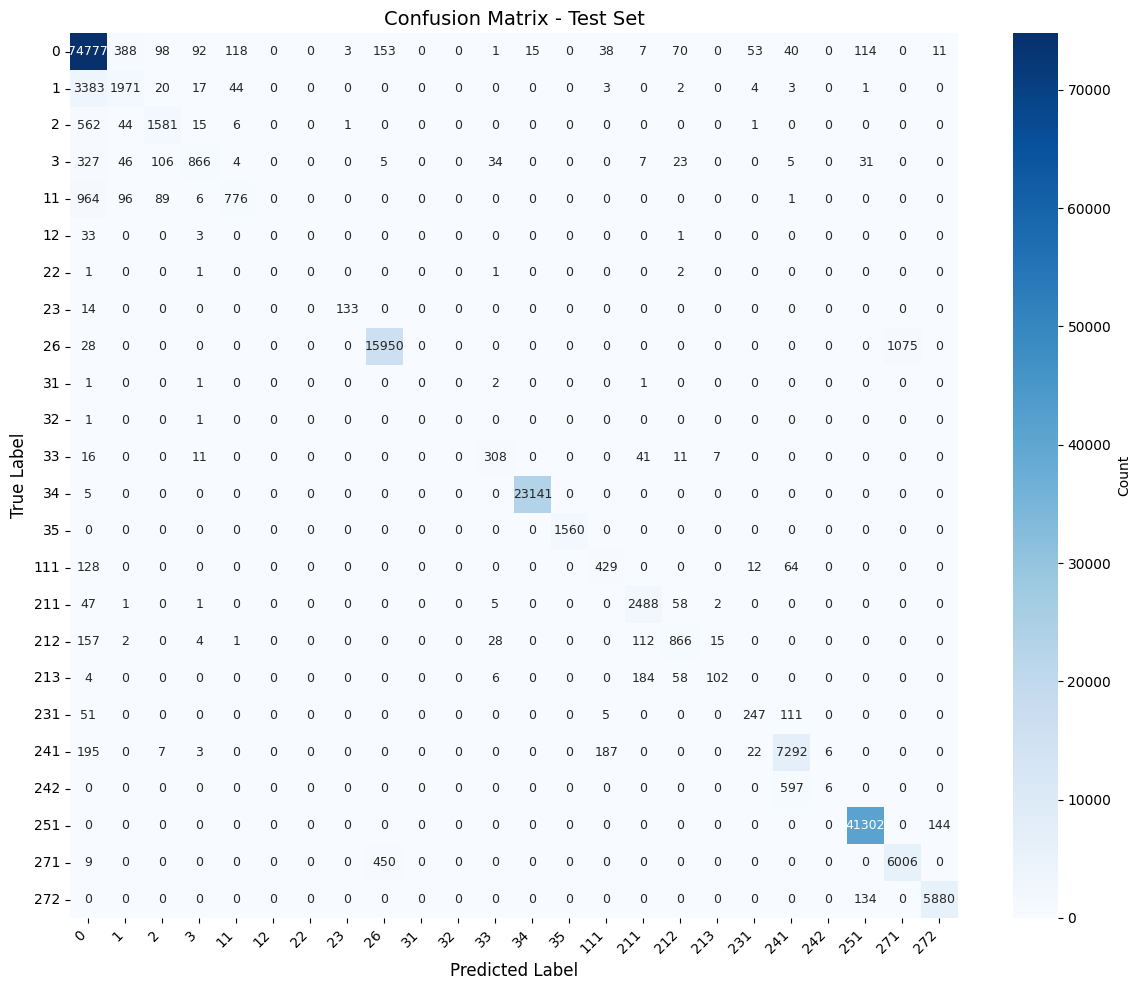

In [11]:
classifier = CatBoostClassifier(
    iterations=500,
    max_depth=7,
    random_seed=2,
    learning_rate=0.1,
    eval_metric="Accuracy",
    loss_function="MultiClass"
)

classifier.fit(
    train_features, train_labels,
    eval_set=(val_features, val_labels),
    verbose=1,
    plot=True
)

plt.figure(figsize=(10, 6))
plt.plot(classifier.evals_result_['learn']['Accuracy'], label='Learn Accuracy')
plt.plot(classifier.evals_result_['validation']['Accuracy'], label='Validation Accuracy')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

print(f"Best Train Accuracy: {classifier.evals_result_['learn']['Accuracy'][-1]}")
print(f"Best Validation Accuracy: {classifier.evals_result_['validation']['Accuracy'][-1]}")

validation_score = classifier.score(val_features, val_labels)
print(f"Score Validation Accuracy: {validation_score}")

test_score = classifier.score(test_features, test_labels)
print(f"Score Test Accuracy: {test_score}")


# CONFUSION MATRIX
test_predictions = classifier.predict(test_features)

cm = confusion_matrix(test_labels, test_predictions)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classifier.classes_, 
            yticklabels=classifier.classes_,
            annot_kws={'size': 9},
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Test Set', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix_test.png', dpi=300, bbox_inches='tight')
plt.show()

In [3]:
classifier.save_model("trained_osc_grid_catboost", format="cbm")